In [23]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import exposure, img_as_float
from scipy import ndimage
import cv2
import random
import os

In [24]:
# Creating directory to save results
os.makedirs("Results", exist_ok=True) 

In [6]:
# Load the NIfTI file
nii_file = nib.load('left_knee.nii.gz')
volume = nii_file.get_fdata()
affine = nii_file.affine

In [7]:
# Taking a central Y-slice for Coronal view
y_index = volume.shape[1] // 2
front_view = volume[:, y_index, :]

In [8]:
# Rotating the image
front_view_rotated = ndimage.rotate(front_view, 90)

# Normalizing the intensity
front_view_norm = (front_view_rotated - np.min(front_view_rotated)) / (np.max(front_view_rotated) - np.min(front_view_rotated))

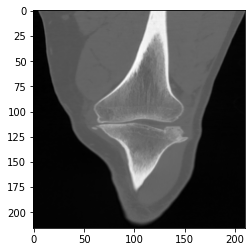

In [9]:
cropped_image = front_view_norm[:, 270:480] 
equalized_img = exposure.rescale_intensity(cropped_image)
plt.imshow(equalized_img, cmap='gray')

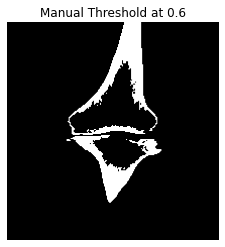

In [11]:
_, binary = cv2.threshold((equalized_img * 255).astype(np.uint8), int(0.5 * 255), 255, cv2.THRESH_BINARY)

plt.imshow(binary,cmap='gray')
plt.title("Manual Threshold at 0.6")
plt.axis('off')
plt.show()

In [12]:
# Morphological operations on binary mask
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1,1))
binary_cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
binary_cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Finding contours from 1-channel binary image
contours,_ = cv2.findContours(binary_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


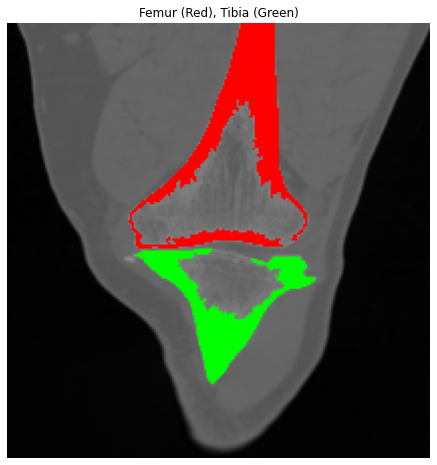

In [38]:
min_area = 500
filtered = [c for c in contours if cv2.contourArea(c) > min_area]

# Sort top to bottom (assumes femur is above tibia)
sorted_contours = sorted(filtered, key=lambda c: cv2.boundingRect(c)[1])

# Convert grayscale to BGR for overlay
overlay = cv2.cvtColor((equalized_img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

# Fill femur and tibia
for i, contour in enumerate(sorted_contours):
    color = (0, 0, 255) if i == 0 else (0, 255, 0)  # Red = femur, Green = tibia
    cv2.drawContours(overlay, [contour], -1, color, thickness=cv2.FILLED)

# Display result
plt.figure(figsize=(8,8))
plt.title("Femur (Red), Tibia (Green)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Saving File
nifti_img = nib.Nifti1Image(overlay, affine)
output_path = os.path.join("Results", "Segmented Mask.nii.gz")
nib.save(nifti_img, output_path)


In [17]:
voxel_spacing = nii_file.header.get_zooms()

print("Voxel spacing (mm):", voxel_spacing)

Voxel spacing (mm): (0.869141, 0.869141, 2.0)


In [39]:
# Desired and maximum required dilation in mm
dilation_mm = 0
# In-plane pixel spacing (X and Y are the same)
pixel_spacing = voxel_spacing[0]

# Calculate kernel radius in pixels
dilation_radius_px = int(np.round(dilation_mm / pixel_spacing))
print("Dilation Radius is:", dilation_radius_px)

Dilation Radius is: 0


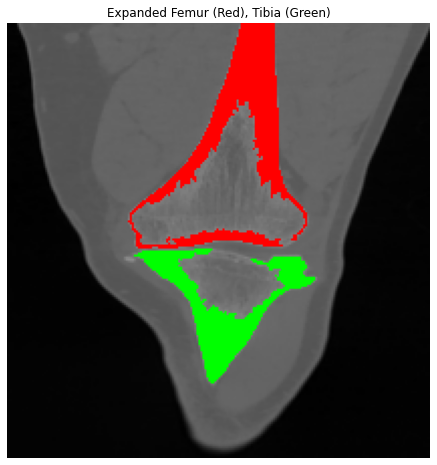

In [40]:
# Creating binary masks for each contour
image_shape = np.zeros_like((equalized_img * 255).astype(np.uint8)).shape
femur_mask = np.zeros(image_shape, dtype=np.uint8)
tibia_mask = np.zeros(image_shape, dtype=np.uint8)

if len(sorted_contours) > 0:
    cv2.drawContours(femur_mask, [sorted_contours[0]], -1, 255, thickness=cv2.FILLED)
if len(sorted_contours) > 1:
    cv2.drawContours(tibia_mask, [sorted_contours[1]], -1, 255, thickness=cv2.FILLED)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*dilation_radius_px+1, 2*dilation_radius_px+1))
femur_dilated = cv2.dilate(femur_mask, kernel)
tibia_dilated = cv2.dilate(tibia_mask, kernel)

# Creating Overlay to mask the original image
overlay = cv2.cvtColor((equalized_img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

overlay[femur_dilated > 0] = (0, 0, 255)   # Red
overlay[tibia_dilated > 0] = (0, 255, 0)   # Green

plt.figure(figsize=(8, 8))
plt.title("Expanded Femur (Red), Tibia (Green)")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [41]:
coords = np.column_stack(np.where(tibia_dilated > 0))
y_min, y_max = np.min(coords[:, 0]), np.max(coords[:, 0])
y_thresh = y_min + 0.1 * (y_max - y_min)
plateau_coords = coords[coords[:, 0] < y_thresh]

if plateau_coords.size == 0:
    print("No plateau points found.")
else:
    # Splitting by midpoint X
    x_min, x_max = np.min(plateau_coords[:, 1]), np.max(plateau_coords[:, 1])
    mid_x = (x_min + x_max) // 2
    medial_coords = plateau_coords[plateau_coords[:, 1] < mid_x]
    lateral_coords = plateau_coords[plateau_coords[:, 1] >= mid_x]

    # Median points based on Y (row)
    if medial_coords.size > 0:
        sorted_medial = medial_coords[np.argsort(medial_coords[:, 0])]
        medial_lowest = sorted_medial[len(sorted_medial) // 2]
        print("Medial plateau point (y, x):", tuple(medial_lowest))
    else:
        print("No medial points in plateau region.")

    if lateral_coords.size > 0:
        sorted_lateral = lateral_coords[np.argsort(lateral_coords[:, 0])]
        lateral_lowest = sorted_lateral[len(sorted_lateral) // 2]
        print("Lateral plateau point (y, x):", tuple(lateral_lowest))
    else:
        print("No lateral points in plateau region.")

file_path = os.path.join("Results", "Original Mask.txt")        
with open(file_path, "w") as f:
    f.write("Medial: {},{}\n".format(medial_lowest[0], medial_lowest[1]))
    f.write("Lateral: {},{}\n".format(lateral_lowest[0], lateral_lowest[1]))

Medial plateau point (y, x): (115, 87)
Lateral plateau point (y, x): (117, 131)


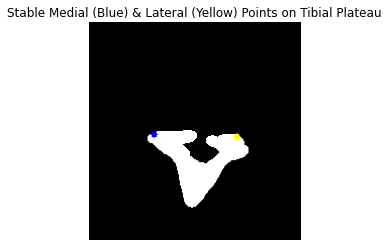

In [30]:
overlay = cv2.cvtColor(tibia_dilated, cv2.COLOR_GRAY2BGR)
if medial_coords.size > 0:
    cv2.circle(overlay, (medial_lowest[1], medial_lowest[0]), 3, (255, 0, 0), -1)  # Blue
if lateral_coords.size > 0:
    cv2.circle(overlay, (lateral_lowest[1], lateral_lowest[0]), 3, (0, 255, 255), -1)  # Yellow

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Stable Medial (Blue) & Lateral (Yellow) Points on Tibial Plateau")
plt.axis('off')
plt.show()

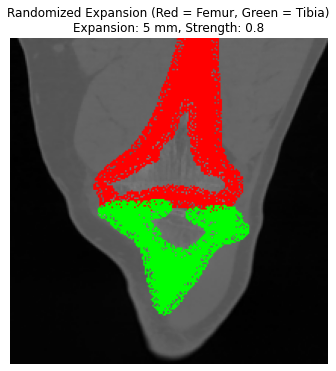

In [34]:
random_strength = 0.8             # probability to include shell pixels (0 to 1)

kernel_size = 2 * dilation_radius_px + 1
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

background = (equalized_img * 255).astype(np.uint8)
base_bgr = cv2.cvtColor(background, cv2.COLOR_GRAY2BGR)

def generate_randomized_mask(original_mask, random_strength):
    dilated_mask = cv2.dilate(original_mask, kernel)

    # Shell = pixels in dilated but not in original
    shell = cv2.subtract(dilated_mask, original_mask)
    shell_binary = (shell > 0).astype(np.uint8)

    # Random binary mask inside shell
    rand_binary = (np.random.rand(*shell.shape) < random_strength).astype(np.uint8)

    # Final mask = original + randomized shell 
    final_mask = np.clip((original_mask > 0).astype(np.uint8) + (rand_binary * shell_binary), 0, 1) * 255
    return final_mask.astype(np.uint8)

femur_random_mask = generate_randomized_mask(femur_mask, random_strength)
tibia_random_mask = generate_randomized_mask(tibia_mask, random_strength)

overlay = base_bgr.copy()
overlay[femur_random_mask > 0] = (0, 0, 255)   
overlay[tibia_random_mask > 0] = (0, 255, 0)   

plt.figure(figsize=(6, 6))
plt.title(f"Randomized Expansion (Red = Femur, Green = Tibia)\nExpansion: {dilation_radius_px} mm, Strength: {random_strength}")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [35]:
coords = np.column_stack(np.where(tibia_random_mask > 0))
y_min, y_max = np.min(coords[:, 0]), np.max(coords[:, 0])
y_thresh = y_min + 0.1 * (y_max - y_min)
plateau_coords = coords[coords[:, 0] < y_thresh]

if plateau_coords.size == 0:
    print("No plateau points found.")
else:
    # Splitting by midpoint X
    x_min, x_max = np.min(plateau_coords[:, 1]), np.max(plateau_coords[:, 1])
    mid_x = (x_min + x_max) // 2
    medial_coords = plateau_coords[plateau_coords[:, 1] < mid_x]
    lateral_coords = plateau_coords[plateau_coords[:, 1] >= mid_x]

    # Median points based on Y (row)
    if medial_coords.size > 0:
        sorted_medial = medial_coords[np.argsort(medial_coords[:, 0])]
        medial_lowest = sorted_medial[len(sorted_medial) // 2]
        print("Medial plateau point (y, x):", tuple(medial_lowest))
    else:
        print("No medial points in plateau region.")

    if lateral_coords.size > 0:
        sorted_lateral = lateral_coords[np.argsort(lateral_coords[:, 0])]
        lateral_lowest = sorted_lateral[len(sorted_lateral) // 2]
        print("Lateral plateau point (y, x):", tuple(lateral_lowest))
    else:
        print("No lateral points in plateau region.")
file_path = os.path.join("Results", "Randomized Mask 2.txt")        
with open(file_path, "w") as f:
    f.write("Medial: {},{}\n".format(medial_lowest[0], medial_lowest[1]))
    f.write("Lateral: {},{}\n".format(lateral_lowest[0], lateral_lowest[1]))

Medial plateau point (y, x): (111, 74)
Lateral plateau point (y, x): (113, 147)


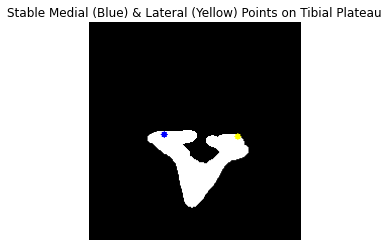

In [36]:
overlay = cv2.cvtColor(tibia_dilated, cv2.COLOR_GRAY2BGR)
if medial_coords.size > 0:
    cv2.circle(overlay, (medial_lowest[1], medial_lowest[0]), 3, (255, 0, 0), -1)  # Blue
if lateral_coords.size > 0:
    cv2.circle(overlay, (lateral_lowest[1], lateral_lowest[0]), 3, (0, 255, 255), -1)  # Yellow

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Stable Medial (Blue) & Lateral (Yellow) Points on Tibial Plateau")
plt.axis('off')
plt.show()